# 02 — Spectral Feature Engineering

Demonstrates how network flows become frequency-domain features for anomaly detection.

**Pipeline:** flows → `build_standard_timeseries()` → Hann-windowed FFT → 13 descriptors × channels → multi-scale matrix (64 s + 256 s when enabled).

## 1. Setup

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.fft import fft, fftfreq

from src.spectral_features import (
    build_standard_timeseries,
    extract_spectral_features,
)
from nb_common import (
    NotebookSettings, load_project_config, load_dataframe,
    build_splits, split_summary, setup_notebook,
)

SETTINGS = NotebookSettings(use_sample=True, use_cache=True)
cfg = load_project_config(SETTINGS)
setup_notebook(cfg)
np.random.seed(42)

## 2. Load Data & Build Time Series

In [2]:
df = load_dataframe(SETTINGS, cfg)
bin_size = cfg['spectral']['bin_size_seconds']
ts_col = 'Timestamp' if 'Timestamp' in df.columns else 'Stime'
ts_df = build_standard_timeseries(df, timestamp_col=ts_col, bin_size_seconds=bin_size)
channels = cfg['spectral'].get('input_series', list(ts_df.columns))
channels = [c for c in channels if c in ts_df.columns]
print('Channels:', channels)
print('Bins:', len(ts_df))
ts_df[channels].describe()

Channels: ['total_bytes', 'total_packets', 'mean_duration']
Bins: 5000


,total_bytes,total_packets,mean_duration
count,5000.000000,5000.000000,5.000000e+03
mean,1299.819003,26.014400,1.803449e+06
std,1503.725019,16.771346,2.876520e+06
min,5.634297,3.000000,1.163482e+01
25%,503.914918,16.000000,3.385737e+05
50%,881.345828,19.000000,8.763127e+05
75%,1500.220393,25.000000,1.934448e+06
max,21652.787767,84.000000,3.103296e+07


## 3. FFT Demonstration (total_bytes)

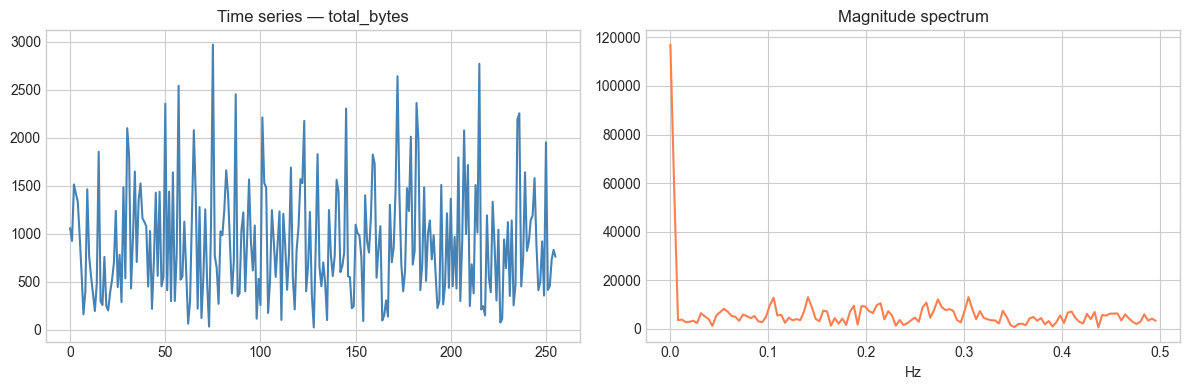

In [3]:
series_name = channels[0] if channels else ts_df.columns[0]
x = ts_df[series_name].values.astype(float)
N = min(256, len(x))
segment = x[:N]
windowed = segment * np.hanning(N)
spectrum = np.abs(fft(windowed))[:N // 2]
freqs = fftfreq(N, d=bin_size)[:N // 2]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(segment, color='steelblue')
axes[0].set_title(f'Time series — {series_name}')
axes[1].plot(freqs, spectrum, color='coral')
axes[1].set_title('Magnitude spectrum')
axes[1].set_xlabel('Hz')
plt.tight_layout()
plt.show()

## 4. Hann Windowing Effect

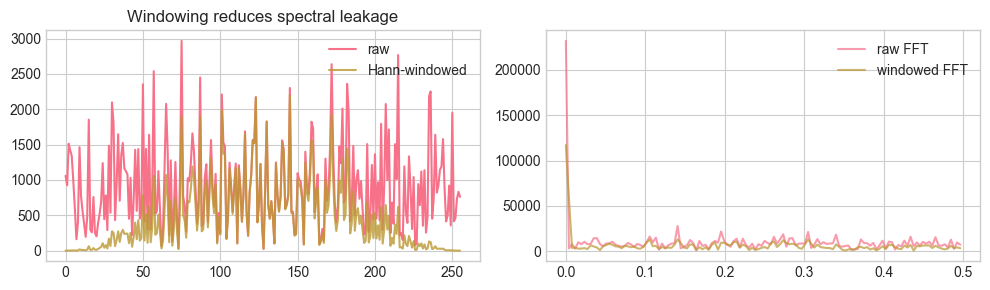

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
axes[0].plot(segment, label='raw')
axes[0].plot(windowed, label='Hann-windowed', alpha=0.8)
axes[0].legend()
axes[0].set_title('Windowing reduces spectral leakage')
raw_spec = np.abs(fft(segment))[:N // 2]
win_spec = np.abs(fft(windowed))[:N // 2]
axes[1].plot(freqs, raw_spec, label='raw FFT', alpha=0.7)
axes[1].plot(freqs, win_spec, label='windowed FFT', alpha=0.7)
axes[1].legend()
plt.tight_layout()
plt.show()

## 5. Spectral Descriptors

In [5]:
desc = extract_spectral_features(segment, fs=1.0 / bin_size, window_fn='hann')
for k, v in desc.items():
    print(f'{k:20s} {v:12.4f}')

spectral_entropy           2.3263
spectral_centroid          0.0691
spectral_flatness          0.1826
spectral_bandwidth         0.1251
dominant_frequency         0.0039
dominant_amplitude   25916124.9948
total_power          112537407.7223
dc_component             906.0183
rolloff_85                 0.2148
rolloff_95                 0.3672
energy_band_0              0.8065
energy_band_1              0.1364
energy_band_2              0.0571


## 6. Build Full Spectral Splits (same as main.py)

In [6]:
splits = build_splits(SETTINGS, cfg, df)
print(split_summary(splits))
print('First 5 feature names:', splits['feat_names'][:5])

Train : 87 windows (benign only)
Val   : 33 windows (45.5% attack)
Test  : 35 windows (45.7% attack)
Features: 90
First 5 feature names: ['fast__total_bytes__spectral_entropy', 'fast__total_bytes__spectral_centroid', 'fast__total_bytes__spectral_flatness', 'fast__total_bytes__spectral_bandwidth', 'fast__total_bytes__dominant_frequency']


## 7. Benign vs Attack Descriptor Preview

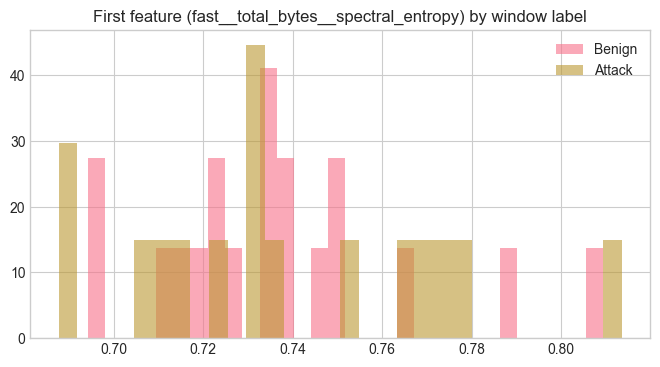

In [7]:
X_test = splits['X_test']
y_test = splits['y_test']
if y_test.sum() > 0 and (y_test == 0).sum() > 0:
    idx_b = np.where(y_test == 0)[0][:50]
    idx_a = np.where(y_test == 1)[0][:50]
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(X_test[idx_b, 0], bins=30, alpha=0.6, label='Benign', density=True)
    ax.hist(X_test[idx_a, 0], bins=30, alpha=0.6, label='Attack', density=True)
    ax.set_title(f'First feature ({splits["feat_names"][0]}) by window label')
    ax.legend()
    plt.show()
else:
    print('Not enough attack/benign windows for comparison plot')